<a href="https://colab.research.google.com/github/sindla97/Machine-Learning/blob/main/census_bureau.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [10]:
columns=pd.read_csv('/content/census-bureau.columns',sep=',',names=['columns'])
columns['columns']=columns['columns'].str.replace(' ','_')
columns

,columns
0,age
1,class_of_worker
2,detailed_industry_recode
3,detailed_occupation_recode
4,education
5,wage_per_hour
6,enroll_in_edu_inst_last_wk
7,marital_stat
8,major_industry_code
9,major_occupation_code


In [78]:
df=pd.read_csv('/content/census-bureau.data', sep=",",names=columns['columns'].tolist())
df.head()

,age,class_of_worker,detailed_industry_recode,detailed_occupation_recode,education,wage_per_hour,enroll_in_edu_inst_last_wk,marital_stat,major_industry_code,major_occupation_code,...,country_of_birth_father,country_of_birth_mother,country_of_birth_self,citizenship,own_business_or_self_employed,fill_inc_questionnaire_for_veteran's_admin,veterans_benefits,weeks_worked_in_year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


In [79]:
df['detailed_occupation_recode']=df['detailed_occupation_recode'].astype('object')
df['detailed_industry_recode']=df['detailed_industry_recode'].astype('object')

In [12]:
df.shape

(199523, 42)

In [44]:
data_type_df=df.dtypes.reset_index(name='data_type')
data_type_df

,index,data_type
0,age,int64
1,class_of_worker,object
2,detailed_industry_recode,object
3,detailed_occupation_recode,object
4,education,object
5,wage_per_hour,int64
6,enroll_in_edu_inst_last_wk,object
7,marital_stat,object
8,major_industry_code,object
9,major_occupation_code,object


In [80]:
df['label']=df['label'].apply(lambda x: 1 if x=='50000+.' else 0)
# df['label']=df['label'].astype('category')

In [81]:
df['label'].value_counts()

,count
label,
0,187141
1,12382


In [82]:
df.groupby('label')['weight'].mean()

,weight
label,
0,1736.683288
1,1796.256279


In [61]:
(df.groupby('label')['weight'].sum()/df['weight'].sum())*100

/tmp/ipython-input-463126443.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (df.groupby('label')['weight'].sum()/df['weight'].sum())*100


,weight
label,
0,93.594958
1,6.405042


In [29]:
df['weight'].describe()

,weight
count,199523.000000
mean,1740.380269
std,993.768156
min,37.870000
25%,1061.615000
50%,1618.310000
75%,2188.610000
max,18656.300000


In [83]:
unique_cnt=[]

for i in data_type_df['index'].tolist():
  #print(data_type_df.loc[data_type_df['index']==i,'data_type'])
  if data_type_df.loc[data_type_df['index'] == i, 'data_type'].iloc[0] == 'object':
    unique_cnt.append(df[i].nunique())
  else: unique_cnt.append(0)
#print(unique_cnt)
data_type_df['nunique']=pd.Series(unique_cnt)
data_type_df

# df['class_of_worker'].unique().tolist()

,index,data_type,nunique
0,age,int64,0
1,class_of_worker,object,9
2,detailed_industry_recode,object,52
3,detailed_occupation_recode,object,47
4,education,object,17
5,wage_per_hour,int64,0
6,enroll_in_edu_inst_last_wk,object,3
7,marital_stat,object,7
8,major_industry_code,object,24
9,major_occupation_code,object,15


(array([13.,  8.,  1.,  1.,  1.,  0.,  0.,  1.,  3.,  3.]),
 array([ 2.,  7., 12., 17., 22., 27., 32., 37., 42., 47., 52.]),
 <BarContainer object of 10 artists>)

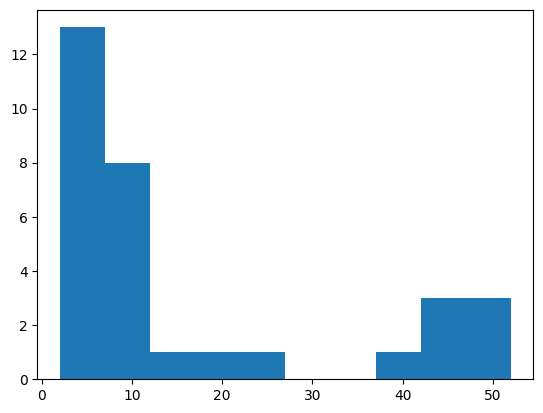

In [97]:
import matplotlib.pyplot as plt
plt.hist(data_type_df.loc[data_type_df['data_type']=='object',['nunique']])
# data_type_df.loc[data_type_df['data_type']=='object',['nunique']].plot.density()

In [59]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(k, r) - 1)))

v_father_mother = cramers_v(df['country_of_birth_father'], df['country_of_birth_mother'])
v_father_self   = cramers_v(df['country_of_birth_father'], df['country_of_birth_self'])
v_mother_self   = cramers_v(df['country_of_birth_mother'], df['country_of_birth_self'])
print(f'v_father_mother:{v_father_mother}; v_father_self:{v_father_self}; v_mother_self:{v_mother_self}' )

v_father_mother:0.7710406662974076; v_father_self:0.6590728604158304; v_mother_self:0.6862108904645999


In [68]:
target='label'
sample_weight='weight'
cat_columns= [x for x in data_type_df.loc[data_type_df['data_type']=='object','index'].tolist() if x not in [target,sample_weight]]
cat_columns
int_columns= [x for x in data_type_df.loc[data_type_df['data_type']=='int64','index'].tolist() if x not in [target,sample_weight]]
int_columns

['age',
 'wage_per_hour',
 'capital_gains',
 'capital_losses',
 'dividends_from_stocks',
 'num_persons_worked_for_employer',
 'own_business_or_self_employed',
 'veterans_benefits',
 'weeks_worked_in_year',
 'year']

In [84]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(
    df,
    random_state=42,
test_size=0.3,stratify=df[target])

In [85]:
print(train_df[target].value_counts(), test_df[target].value_counts())

label
0    130999
1      8667
Name: count, dtype: int64 label
0    56142
1     3715
Name: count, dtype: int64


In [87]:
global_mean = train_df[target].mean()

for feature in cat_columns:

  mean_map = train_df.groupby(feature)[target].mean()


  train_df[f'{feature}_enc_mt'] = train_df[feature].map(mean_map)
  test_df[f'{feature}_enc_mt']  = test_df[feature].map(mean_map)

  pop_map = train_df[feature].value_counts()
  train_df[f'{feature}_enc_pop'] = train_df[feature].map(pop_map)
  test_df[f'{feature}_enc_pop']  = test_df[feature].map(pop_map)

# Handle unknown categories in test
  test_df[f'{feature}_enc_mt'].fillna(global_mean, inplace=True)
  test_df[f'{feature}_enc_pop'].fillna(global_mean, inplace=True)

/tmp/ipython-input-2150900700.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df[f'{feature}_enc_mt'].fillna(global_mean, inplace=True)
/tmp/ipython-input-2150900700.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [88]:
train_df.describe()

,age,wage_per_hour,capital_gains,capital_losses,dividends_from_stocks,weight,num_persons_worked_for_employer,own_business_or_self_employed,veterans_benefits,weeks_worked_in_year,...,country_of_birth_father_enc_mt,country_of_birth_father_enc_pop,country_of_birth_mother_enc_mt,country_of_birth_mother_enc_pop,country_of_birth_self_enc_mt,country_of_birth_self_enc_pop,citizenship_enc_mt,citizenship_enc_pop,fill_inc_questionnaire_for_veteran's_admin_enc_mt,fill_inc_questionnaire_for_veteran's_admin_enc_pop
count,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,...,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000
mean,34.468983,55.758853,441.344107,37.868995,201.836438,1740.683954,1.955050,0.176063,1.513640,23.152614,...,0.062055,89276.713459,0.062055,90688.011714,0.062055,109968.268555,0.062055,110560.374823,0.062055,136928.919322
std,22.315965,279.575713,4754.165212,274.515022,2064.608176,994.066463,2.365581,0.554511,0.852232,24.405993,...,0.017741,43589.262662,0.017490,43477.406202,0.015483,38745.111915,0.009957,37110.276833,0.006185,13584.950616
min,0.000000,0.000000,0.000000,0.000000,0.000000,37.870000,0.000000,0.000000,0.000000,0.000000,...,0.000000,16.000000,0.000000,18.000000,0.000000,14.000000,0.018692,1070.000000,0.029091,275.000000
25%,15.000000,0.000000,0.000000,0.000000,0.000000,1061.570000,0.000000,0.000000,2.000000,0.000000,...,0.064790,111282.000000,0.064816,112194.000000,0.063000,123825.000000,0.062999,123827.000000,0.061583,138286.000000
50%,33.000000,0.000000,0.000000,0.000000,0.000000,1617.895000,1.000000,0.000000,2.000000,8.000000,...,0.064790,111282.000000,0.064816,112194.000000,0.063000,123825.000000,0.062999,123827.000000,0.061583,138286.000000
75%,50.000000,0.000000,0.000000,0.000000,0.000000,2189.980000,4.000000,0.000000,2.000000,52.000000,...,0.064790,111282.000000,0.064816,112194.000000,0.063000,123825.000000,0.062999,123827.000000,0.061583,138286.000000
max,90.000000,9999.000000,99999.000000,4608.000000,99999.000000,18656.300000,6.000000,2.000000,2.000000,52.000000,...,0.140436,111282.000000,0.151515,112194.000000,0.186916,123825.000000,0.099347,123827.000000,0.129412,138286.000000


(array([130904.,   1771.,   1890.,    544.,   1177.,   1573.,    506.,
           586.,    319.,    396.]),
 array([ 0. ,  4.2,  8.4, 12.6, 16.8, 21. , 25.2, 29.4, 33.6, 37.8, 42. ]),
 <BarContainer object of 10 artists>)

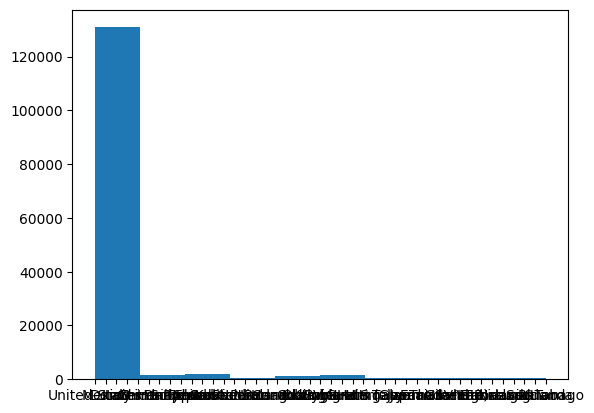

In [100]:
plt.hist(train_df['country_of_birth_self'])

<Axes: ylabel='Density'>

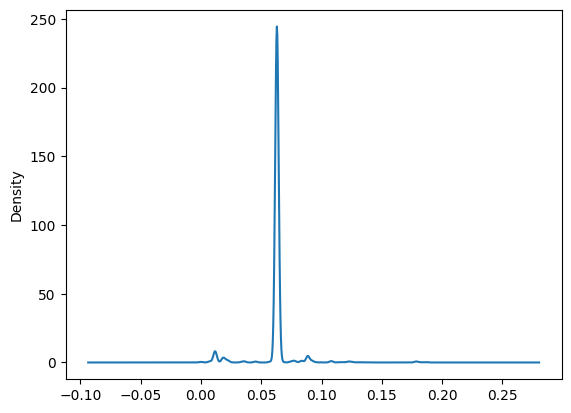

In [99]:
train_df['country_of_birth_self_enc_mt'].plot.kde()